## 1. Transcripción Automatizada del Audio (ASR)

En esta primera etapa procesamos las retransmisiones en formato audio (`.mp3`) para extraer el texto transcrito junto con sus marcas de tiempo exactas (`start` y `end`).

**Puntos clave del procesamiento:**
* **Modelo:** Se utiliza `faster-whisper` con el *checkpoint* `large-v3` sobre GPU (`cuda` en `float16`) para optimizar la velocidad de inferencia sin perder precisión léxica.
* **Control de alucinaciones:** Se fija `condition_on_previous_text=False` para evitar que el modelo entre en bucles de repetición provocados por el ruido de fondo, cánticos o murmullos del estadio.
* **Búsqueda:** Se emplea `beam_size=5` para priorizar la coherencia global del discurso de los comentaristas.
* **Caché:** Se comprueba la existencia de transcripciones previas para evitar reprocesar archivos JSON ya generados.

In [8]:
import os
import json
import time
from faster_whisper import WhisperModel

# 1. Configuración de directorios
audio_dir = os.path.join("..", "data", "transcripts")
transcript_dir = os.path.join("..", "data", "transcripts")
os.makedirs(transcript_dir, exist_ok=True)

# 2. Carga del modelo)
# device="cuda" y compute_type="float16"
model = WhisperModel("large-v3", device="cuda", compute_type="float16")
print("Modelo cargado correctamente. Iniciando procesamiento...\n")

# 3. Bucle de transcripción
for file in os.listdir(audio_dir):
    if file.endswith(".mp3"):
        audio_path = os.path.join(audio_dir, file)
        json_file = f"{os.path.splitext(file)[0]}.json"
        json_path = os.path.join(transcript_dir, json_file)
        
        # Sistema de caché: evitamos reprocesar si el JSON ya existe
        if os.path.exists(json_path):
            print(f"Saltando '{file}', ya existe su transcripción.")
            continue
            
        print(f"Transcribiendo: {file}...")
        start_time = time.time()
        
        # beam_size=5 mejora la coherencia del texto a costa de un poco de velocidad
        # condition_on_previous_text=False evita que el modelo entre en bucles de alucinación con el ruido del estadio
        segments, info = model.transcribe(
            audio_path, 
            language="es",
            beam_size=5,
            condition_on_previous_text=False 
        )
        
        print(f"Detectado idioma '{info.language}' con probabilidad {info.language_probability:.2f}")
        
        # faster-whisper devuelve un generador, iteramos para extraer los datos
        transcription_data = []
        for segment in segments:
            transcription_data.append({
                "id": segment.id,
                "start": segment.start,
                "end": segment.end,
                "text": segment.text.strip()
            })
            
        # Guardado estructurado en JSON
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(transcription_data, f, ensure_ascii=False, indent=4)
            
        elapsed_time = time.time() - start_time
        print(f"✔ Transcripción guardada en {json_path} (Tiempo: {elapsed_time:.2f} segundos)\n")

Modelo cargado correctamente. Iniciando procesamiento...

Transcribiendo: España - Arabia Saudí ｜ Grupo H ｜ Fase de grupos.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Arabia Saudí ｜ Grupo H ｜ Fase de grupos.json (Tiempo: 354.19 segundos)

Transcribiendo: España - Argentina ｜ Mundial FIFA 2026.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Argentina ｜ Mundial FIFA 2026.json (Tiempo: 695.24 segundos)

Transcribiendo: España - Austria ｜ Dieciseisavos de final.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Austria ｜ Dieciseisavos de final.json (Tiempo: 397.94 segundos)

Transcribiendo: España - Bélgica ｜ Cuartos de final.mp3...
Detectado idioma 'es' con probabilidad 1.00
✔ Transcripción guardada en ..\data\transcripts\España - Bélgica ｜ Cuartos de final.json (Tiempo: 375.07 segundos)

Transcribiendo: España

## 2. Filtrado y Normalización Temporal de las Transcripciones

Los archivos de audio brutos contienen pausas, publicidad previa, tiempo de descanso o análisis post-partido. Para analizar con precisión la dinámica temporal del juego, este bloque filtra y estructura los datos según los límites efectivos del encuentro.

**Puntos clave del procesamiento:**
* **Metadatos temporales:** Se leen los intervalos de tiempo reales (`1P`, `2P`, `TE`, `PEN`) almacenados en `matches metadata.json`. Han sido generados a través de gemini aportandole los json originales, se ha hecho comprobación manual posterior
* **Emparejamiento flexible:** Se tokenizan las claves de los partidos (ej. `espana_francia`) para asociar dinámicamente cada archivo independientemente del orden de los equipos en el nombre del `.mp3`.
* **Cálculo de tiempo relativo ($t_{rel}$):** Además de conservar los *timestamps* absolutos del archivo, se calcula el tiempo en segundos desde el inicio exacto de cada parte ($t_{rel} = t_{abs} - t_{inicio\_periodo}$). Esto facilita el alineamiento minuto a minuto para el modelado posterior de series temporales.
* **Almacenamiento estructurado:** Los datos limpios se exportan en formato JSON a la carpeta `data/clean_transcripts/`.

In [15]:
import re
import unicodedata

# 1. Configuración de directorios
data_dir = os.path.join("..", "data")
transcripts_dir = os.path.join(data_dir, "transcripts")
clean_dir = os.path.join(data_dir, "clean_transcripts")
os.makedirs(clean_dir, exist_ok=True)

# Ruta del archivo de metadatos
metadata_path = os.path.join(transcripts_dir, "matches metadata.json")

# 2. Carga dinámica de metadatos desde el archivo JSON
with open(metadata_path, "r", encoding="utf-8") as f:
    match_metadata = json.load(f)

# Función para normalizar texto (quita acentos y caracteres especiales)
def normalize_string(text):
    text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore').decode("utf-8")
    return re.sub(r'[^a-zA-Z0-9\s_]', '', text).lower()

# Listar todos los JSON de transcripciones brutas
raw_json_files = [
    f for f in os.listdir(transcripts_dir) 
    if f.endswith(".json") and f != os.path.basename(metadata_path)
]

# 3. Procesamiento y filtrado de las transcripciones
for match_key, intervals in match_metadata.items():
    # Extraemos las palabras clave dividiendo por '_' (ej. ['espana', 'francia'])
    key_terms = [normalize_string(term) for term in match_key.split('_') if term]
    
    # Buscamos un archivo que contenga TODAS las palabras clave de la llave
    matching_file = None
    for f in raw_json_files:
        norm_file_name = normalize_string(f)
        if all(term in norm_file_name for term in key_terms):
            matching_file = f
            break
    
    if not matching_file:
        print(f"No se encontró archivo transcrito para la clave: '{match_key}'")
        continue

    raw_file_path = os.path.join(transcripts_dir, matching_file)
    with open(raw_file_path, "r", encoding="utf-8") as f:
        segments = json.load(f)

    clean_segments = []
    
    for seg in segments:
        seg_start = seg["start"]
        seg_end = seg["end"]
        
        # Evaluar en qué periodo del partido (1P, 2P, TE, PEN) encaja el segmento
        for period, times in intervals.items():
            if times is not None:
                if seg_start >= times["start"] and seg_end <= times["end"]:
                    clean_segments.append({
                        "id": seg["id"],
                        "period": period,
                        "start": seg_start,
                        "end": seg_end,
                        "relative_start": round(seg_start - times["start"], 2),
                        "relative_end": round(seg_end - times["start"], 2),
                        "text": seg["text"]
                    })
                    break 

    # Guardar la transcripción limpia
    output_filename = f"{match_key}_clean.json"
    output_path = os.path.join(clean_dir, output_filename)
    
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(clean_segments, f, ensure_ascii=False, indent=4)

    print(f"Procesado: {match_key} -> {len(clean_segments)} segmentos guardados en {output_filename}")

Procesado: espana_arabia_saudi -> 2253 segmentos guardados en espana_arabia_saudi_clean.json
Procesado: espana_argentina -> 3827 segmentos guardados en espana_argentina_clean.json
Procesado: espana_austria -> 2241 segmentos guardados en espana_austria_clean.json
Procesado: espana_belgica -> 2466 segmentos guardados en espana_belgica_clean.json
Procesado: espana_cabo_verde -> 2469 segmentos guardados en espana_cabo_verde_clean.json
Procesado: espana_francia -> 2639 segmentos guardados en espana_francia_clean.json
Procesado: espana_portugal -> 2524 segmentos guardados en espana_portugal_clean.json
Procesado: espana_uruguay -> 2618 segmentos guardados en espana_uruguay_clean.json


## 3. Reconocimiento de Entidades (NER) y Análisis de Sentimiento por Segmento

En esta etapa enriquecemos el conjunto de transcripciones filtradas extrayendo dos dimensiones fundamentales: las menciones a los integrantes de la Selección Española y la polaridad emocional del discurso de los comentaristas en cada instante.

**Puntos clave de la metodología:**
* **Normalización de Entidades y Diccionario de Alias:** Tras auditar las transcripciones generadas por Whisper, se detectó un número significativo de desviaciones fonéticas y errores ortográficos en los nombres propios (ej. *"Ollarzabal"*[cite: 4], *"Kubarsin"*[cite: 4], *"la Min"*[cite: 4] o *"Alevaina"*[cite: 4]). Para resolver esto, **se ha utilizado Gemini para mapear la plantilla oficial de la RFEF y detectar automáticamente las posibles variantes transcritas**. Con ello se ha construido un diccionario canónico que vincula alias y aberraciones fonéticas con la identidad oficial de cada futbolista.
* **Extracción de Entidades con Regex Boundings:** Se implementa un algoritmo de emparejamiento por límites de palabra (`\b`) ordenado por longitud descendente de alias. Esto garantiza que términos complejos (ej. *"Lamine Yamal"*) se procesen antes que sus partes (*"Lamine"*) y evita falsos positivos por subcadenas en el texto.
* **Análisis de Sentimiento Transformer:** Se aplica el modelo `pysentimiento` (RoBERTa preentrenado en español) a cada segmento para obtener las probabilidades de las clases Positivo (`POS`), Negativo (`NEG`) y Neutro (`NEU`).
* **Indicador de Polaridad Neta ($S_t$):** Se define un índice continuo $S_t = P(\text{POS})_t - P(\text{NEG})_t \in [-1, 1]$ que cuantifica la inclinación emocional de la narración en cada tramo del partido.
* **Consolidación de Datos:** Los resultados procesados de todos los encuentros se integran en un conjunto de datos consolidado y se exportan en formatos Parquet (`data/processed/sentiment_ner_dataset.parquet`) y CSV para las etapas de modelado de grafos y series temporales.

In [18]:
import pandas as pd
import spacy
from pysentimiento import create_analyzer

# 1. Configuración de directorios
data_dir = os.path.join("..", "data")
clean_dir = os.path.join(data_dir, "clean_transcripts")
processed_dir = os.path.join(data_dir, "processed")
os.makedirs(processed_dir, exist_ok=True)

# 2. Carga del CSV de jugadores para construir el mapeo oficial
df_players = pd.read_csv(os.path.join(data_dir, "jugadores_esp.csv"))

# Diccionario de alias con variantes oficiales y errores comunes detectados de Whisper
PLAYER_ALIASES = {
    "Unai Simón": ["unai simon", "unai simón", "unai", "simon", "simón", "unesimon", "unesimón"],
    "David Raya": ["david raya", "raya"],
    "Joan García": ["joan garcia", "joan garcía"],
    "Marc Pubill": ["marc pubill", "pubill"],
    "Álex Grimaldo": ["alex grimaldo", "álex grimaldo", "grimaldo"],
    "Eric García": ["eric garcia", "eric garcía"],
    "Marcos Llorente": ["marcos llorente", "llorente"],
    "Pedro Porro": ["pedro porro", "porro"],
    "Aymeric Laporte": ["aymeric laporte", "laporte", "balapor"],
    "Pau Cubarsí": ["pau cubarsi", "pau cubarsí", "cubarsi", "cubarsí", "cubarsin", "cubarsín", "kubarsin", "kubarsy", "kubarsik", "pauco barcis"],
    "Marc Cucurella": ["marc cucurella", "cucurella", "kukureya", "cucurilla", "curella"],
    "Mikel Merino": ["mikel merino", "merino"],
    "Fabián Ruiz": ["fabian ruiz", "fabián ruiz", "fabian", "fabián", "fabiana"],
    "Gavi": ["gavi"],
    "Dani Olmo": ["dani olmo", "daniel olmo", "olmo", "danielmo"],
    "Álex Baena": ["alex baena", "álex baena", "baena", "sbaena", "alevaina", "vales baena"],
    "Rodri": ["rodri", "rodrigo hernandez", "rodrigo hernández"],
    "Martín Zubimendi": ["martin zubimendi", "martín zubimendi", "zubimendi", "zubi", "subil"],
    "Ferran Torres": ["ferran torres", "ferran", "ferrán"],
    "Yeremy Pino": ["yeremy pino", "yeremy"],
    "Nico Williams": ["nico williams", "williams", "nico"],
    "Lamine Yamal": ["lamine yamal", "lamine", "yamal", "lamin", "la min", "la mim", "mini"],
    "Pedri": ["pedri", "pedri gonzalez"],
    "Mikel Oyarzabal": ["mikel oyarzabal", "oyarzabal", "ollarzabal", "arzabal", "jarzabal", "ollantrabal", "yarzabal"],
    "Víctor Muñoz": ["victor muñoz", "víctor muñoz", "victor munoz"],
    "Borja Iglesias": ["borja iglesias", "iglesias", "panda"]
}

# Invertir el diccionario para una búsqueda rápida: alias_normalizado -> Nombre Oficial
ALIAS_TO_CANONICAL = {}
for canonical_name, aliases in PLAYER_ALIASES.items():
    for alias in aliases:
        ALIAS_TO_CANONICAL[alias.lower()] = canonical_name

# Función auxiliar para quitar acentos
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFD', input_str)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

def extract_players_from_text(text):
    """Detecta menciones a jugadores considerando errores de transcripción."""
    text_clean = remove_accents(text.lower())
    detected_players = set()
    
    # Ordenar alias por longitud descendente para emparejar 'lamine yamal' antes que 'lamine'
    sorted_aliases = sorted(ALIAS_TO_CANONICAL.keys(), key=len, reverse=True)
    
    for alias in sorted_aliases:
        alias_clean = remove_accents(alias)
        # Búsqueda por palabra exacta mediante Regex
        pattern = r'\b' + re.escape(alias_clean) + r'\b'
        if re.search(pattern, text_clean):
            canonical_name = ALIAS_TO_CANONICAL[alias]
            detected_players.add(canonical_name)
            
    return list(detected_players)

# 3. Carga de modelos de NLP y Sentimiento
print("Cargando modelo de Sentimiento (pysentimiento)...")
sentiment_analyzer = create_analyzer(task="sentiment", lang="es")

# 4. Procesamiento de todos los JSON limpios
clean_files = [f for f in os.listdir(clean_dir) if f.endswith("_clean.json")]
all_rows = []

for file_name in clean_files:
    match_id = file_name.replace("_clean.json", "")
    file_path = os.path.join(clean_dir, file_name)
    
    with open(file_path, "r", encoding="utf-8") as f:
        segments = json.load(f)
        
    print(f"Procesando NLP y Sentimiento para: {match_id} ({len(segments)} segmentos)...")
    
    for seg in segments:
        text = seg["text"]
        if not text:
            continue
            
        # Analizar sentimiento
        sent_res = sentiment_analyzer.predict(text)
        pos_score = sent_res.probas["POS"]
        neg_score = sent_res.probas["NEG"]
        neu_score = sent_res.probas["NEU"]
        
        # Extraer jugadores con el mapeo canónico
        players = extract_players_from_text(text)
        
        all_rows.append({
            "match_id": match_id,
            "segment_id": seg["id"],
            "period": seg["period"],
            "start": seg["start"],
            "end": seg["end"],
            "relative_start": seg["relative_start"],
            "relative_end": seg["relative_end"],
            "text": text,
            "players": players,
            "players_count": len(players),
            "sentiment_label": sent_res.output, # POS, NEG, NEU
            "pos_score": pos_score,
            "neg_score": neg_score,
            "neu_score": neu_score,
            "net_polarity": pos_score - neg_score  # Métrica continua (-1 a +1)
        })

# 5. Guardar resultado consolidado
df_results = pd.DataFrame(all_rows)

output_parquet = os.path.join(processed_dir, "sentiment_ner_dataset.parquet")
output_csv = os.path.join(processed_dir, "sentiment_ner_dataset.csv")

df_results.to_parquet(output_parquet, index=False)
df_results.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"\n ¡Procesamiento completado con éxito!")
print(f"  - Registros procesados: {len(df_results)}")
print(f"  - Guardado Parquet: {output_parquet}")
print(f"  - Guardado CSV: {output_csv}")

Cargando modelo de Sentimiento (pysentimiento)...


c:\Users\marti\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\marti\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11823.39it/s]


Procesando NLP y Sentimiento para: espana_arabia_saudi (2253 segmentos)...
Procesando NLP y Sentimiento para: espana_argentina (3827 segmentos)...
Procesando NLP y Sentimiento para: espana_austria (2241 segmentos)...
Procesando NLP y Sentimiento para: espana_belgica (2466 segmentos)...
Procesando NLP y Sentimiento para: espana_cabo_verde (2469 segmentos)...
Procesando NLP y Sentimiento para: espana_francia (2639 segmentos)...
Procesando NLP y Sentimiento para: espana_portugal (2524 segmentos)...
Procesando NLP y Sentimiento para: espana_uruguay (2618 segmentos)...

 ¡Procesamiento completado con éxito!
  - Registros procesados: 21037
  - Guardado Parquet: ..\data\processed\sentiment_ner_dataset.parquet
  - Guardado CSV: ..\data\processed\sentiment_ner_dataset.csv


## 4. Análisis de Sentimiento por Jugador y Grafos de Co-ocurrencia de la Narrativa

En este bloque explotamos el dataset consolidado (`sentiment_ner_dataset.parquet`) para extraer métricas topológicas de red y construir el perfil emocional acumulado por cada futbolista a lo largo del Mundial.

**Puntos clave del análisis:**
* **Perfil Emocional por Jugador:** Agregamos el léxico y la polaridad neta ($S_t$) asociada a cada mención de un jugador para identificar quiénes acumulan una narrativa más positiva (euforia/alabanzas) y cuáles concentran mayor negatividad (críticas, tensión o faltas sufridas).
* **Construcción de la Red de Co-ocurrencia:** Modelamos la retransmisión como un **grafo no dirigido $G = (V, E)$**, donde los nodos $V$ representan a los jugadores y las aristas $E$ tienen un peso $w_{ij}$ equivalente al número de veces que dos futbolistas coinciden en la misma frase o segmento narrativo (ej. *"pase de Pedri para Lamine"*).
* **Métricas Topológicas:** Calculamos métricas de centralidad como **Betweenness Centrality** (jugadores que actúan como "puentes" en la narrativa) y **Degree Centrality** (los verdaderos *hubs* o focos del partido).
* **Evolución Temporal:** Comparamos la estructura de la red entre las distintas fases del torneo (Fase de Grupos vs. Eliminatorias y Final) para observar cómo se concentra la narrativa del equipo según sube la exigencia del torneo.

=== 1. Métricas Emocionales por Jugador ===
         players  menciones  pos_promedio  neg_promedio  polaridad_neta_promedio  volatilidad_emocional
   Nico Williams        254      0.281943      0.223729                 0.058214               0.424120
           Rodri        683      0.297476      0.243481                 0.053996               0.446566
     Fabián Ruiz        320      0.258382      0.256569                 0.001814               0.436205
Martín Zubimendi         19      0.231139      0.244552                -0.013412               0.417490
      Unai Simón        282      0.250769      0.291210                -0.040441               0.449280
      Álex Baena        475      0.250173      0.303279                -0.053105               0.463608
       Dani Olmo        534      0.250356      0.315977                -0.065620               0.440556
     Pedro Porro        448      0.207371      0.274918                -0.067547               0.387220
     Pau Cubarsí    

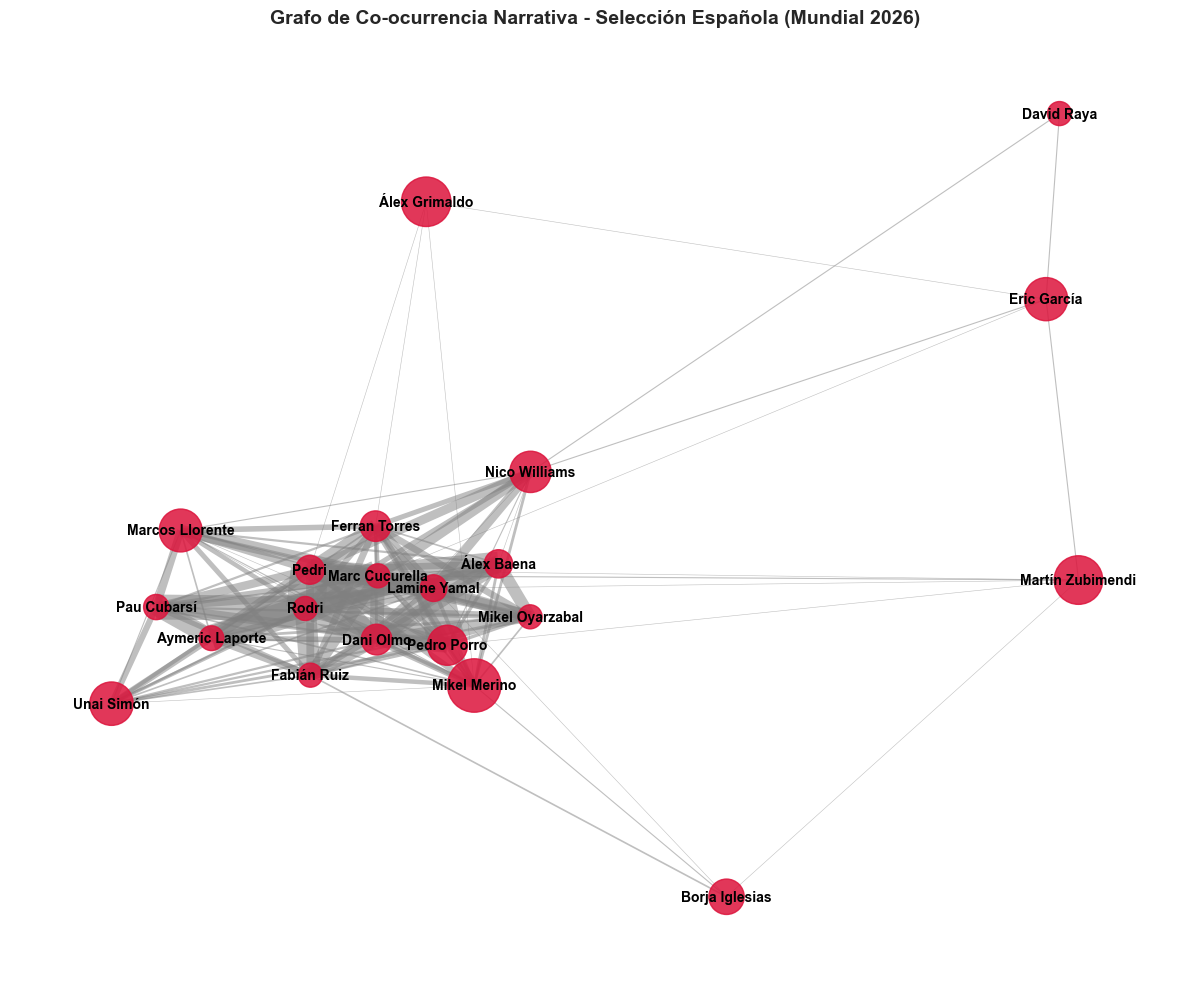


✔ ¡Análisis completado! Grafo exportado en: ..\data\processed\grafo_coocurrencia.png


In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Configuración estilística
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# 1. Carga de datos procesados
processed_dir = os.path.join("..", "data", "processed")
dataset_path = os.path.join(processed_dir, "sentiment_ner_dataset.parquet")

df = pd.read_parquet(dataset_path)

# Explotar la lista de jugadores por segmento para análisis individual
df_exploded = df.explode("players")
df_exploded = df_exploded.dropna(subset=["players"])

# --- A. ANÁLISIS DE SENTIMIENTO ACUMULADO POR JUGADOR ---
print("=== 1. Métricas Emocionales por Jugador ===")
player_stats = df_exploded.groupby("players").agg(
    menciones=("players_count", "count"),
    pos_promedio=("pos_score", "mean"),
    neg_promedio=("neg_score", "mean"),
    polaridad_neta_promedio=("net_polarity", "mean"),
    volatilidad_emocional=("net_polarity", "std")
).reset_index()

# Filtrar jugadores con un mínimo de menciones para evitar sesgos de muestra pequeña
player_stats_filtered = player_stats[player_stats["menciones"] >= 15].sort_values(
    by="polaridad_neta_promedio", ascending=False
)

print(player_stats_filtered.to_string(index=False))

# --- B. CONSTRUCCIÓN DEL GRAFO DE CO-OCURRENCIA GLOBAL ---
print("\n=== 2. Construcción y Métricas de Red (NetworkX) ===")

G = nx.Graph()

# Iterar por segmentos con más de un jugador para agregar aristas
for players_in_seg in df["players"]:
    unique_players = list(set(players_in_seg))
    if len(unique_players) > 1:
        for p1, p2 in combinations(unique_players, 2):
            if G.has_edge(p1, p2):
                G[p1][p2]["weight"] += 1
            else:
                G.add_edge(p1, p2, weight=1)

# Cálculo de Métricas Topológicas
degree_dict = dict(G.degree(weight="weight"))
betweenness_dict = nx.betweenness_centrality(G, weight="weight")
eigenvector_dict = nx.eigenvector_centrality(G, max_iter=1000, weight="weight")

df_network_metrics = pd.DataFrame({
    "Jugador": list(degree_dict.keys()),
    "Grado_Ponderado": list(degree_dict.values()),
    "Betweenness_Centrality": [betweenness_dict[k] for k in degree_dict.keys()],
    "Eigenvector_Centrality": [eigenvector_dict[k] for k in degree_dict.keys()]
}).sort_values(by="Betweenness_Centrality", ascending=False)

print("\n--- Principales Hubs Narrativos de la Selección ---")
print(df_network_metrics.head(10).to_string(index=False))

# --- C. VISUALIZACIÓN DEL GRAFO DE RED ---
plt.figure(figsize=(12, 10))

# Posicionamiento de nodos mediante algoritmo de repulsión de muelles (Fruchterman-Reingold)
pos = nx.spring_layout(G, k=0.5, seed=42)

# Tamaño de nodos proporcional a su Betweenness Centrality
node_sizes = [betweenness_dict[node] * 5000 + 300 for node in G.nodes()]

# Grosor de las aristas proporcional a las apariciones conjuntas
weights = [G[u][v]["weight"] * 0.4 for u, v in G.edges()]

# Dibujar componentes de la red
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="crimson", alpha=0.85)
nx.draw_networkx_edges(G, pos, width=weights, edge_color="gray", alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight="bold")

plt.title("Grafo de Co-ocurrencia Narrativa - Selección Española (Mundial 2026)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()

# Guardar la figura en la carpeta processed
output_graph_path = os.path.join(processed_dir, "grafo_coocurrencia.png")
plt.savefig(output_graph_path, dpi=300)
plt.show()

print(f"\n✔ ¡Análisis completado! Grafo exportado en: {output_graph_path}")

## Interpretación de Resultados: Perfil Emocional y Topología de Red Narrativa

Los resultados obtenidos ofrecen una visión muy reveladora sobre cómo los comentaristas construyen la narrativa de los partidos de la Selección y qué rol juega cada futbolista en el flujo del partido.

---

### 0. Fundamentos del Grafo de Co-ocurrencia $G = (V, E)$

Un **grafo de co-ocurrencia** representa matemáticamente las interacciones o menciones conjuntas entre elementos dentro de una misma ventana de texto (en este caso, los segmentos de transcripción de Whisper):

* **Componentes:** Los **nodos ($V$)** son los futbolistas de la Selección y las **aristas ($E$)** conectan dos jugadores si aparecen nombrados en la misma frase. El **peso ($w_{ij}$)** refleja cuántas veces han coincidido.
* **Métricas Clave:**
  * **Grado Ponderado ($k_i = \sum_{j} w_{ij}$):** Mide el volumen bruto de interacción en la retransmisión.
  * **Centralidad de Intermediación (*Betweenness Centrality*):** Mide la frecuencia con la que un jugador actúa como "puente" en el camino más corto entre otros dos nodos. Puntos altos identifican a conectores entre el núcleo titular y los suplentes/revulsivos.
  * **Centralidad de Autovector (*Eigenvector Centrality*):** Mide la influencia relativa de un jugador basándose en si está conectado con otros nodos altamente transitados e importantes del sistema.
* **Layout Espacial:** La visualización utiliza el algoritmo de muelles (*Fruchterman-Reingold*), donde aristas con mayor peso ejercen más fuerza de atracción, agrupando a los jugadores que combinan con mayor frecuencia.

---

### 1. Análisis del Perfil Emocional por Jugador

Al analizar la polaridad neta promedio ($\bar{S} = \text{POS} - \text{NEG}$) y el número de menciones, observamos tres perfiles claramente diferenciados:

* **Los "Anclajes Positivos" (Nico Williams, Rodri, Fabián Ruiz):**
  * **Rodri (683 menciones, $\bar{S} = +0.054$):** Es el jugador de campo más mencionado dentro del perfil positivo. Al ser el eje de distribución, acumula comentarios de elogio hacia el control, el ritmo y la seguridad en la posesión.
  * **Nico Williams (254 menciones, $\bar{S} = +0.058$):** Mantiene la polaridad neta positiva más alta del equipo. Sus intervenciones suelen estar ligadas a acciones individuales de desborde y regate exitoso, generando picos de optimismo en la locución.

* **Los "Ejes de Tensión y Volumen" (Lamine Yamal, Pedri, Dani Olmo):**
  * **Lamine Yamal (941 menciones, $\bar{S} = -0.111$):** Es el futbolista con mayor volumen absoluto de atención mediática de todo el torneo. Su polaridad neta ligeramente negativa no implica un mal rendimiento, sino su sobreexposición en zonas de alto riesgo: encarar a laterales rivales, faltas recibidas, pérdidas por arriesgar en el regate e interrupciones del juego.
  * **Pedri (643 menciones) y Dani Olmo (534 menciones):** Operan en la mediapunta y zona de creación. Acumulan valores de negatividad derivados de la presión sofocante de las defensas rivales, balones divididos y pases filtrados interceptados.

* **El "Pararrayos del Sufrimiento" (Mikel Merino, Marcos Llorente):**
  * **Marcos Llorente ($\bar{S} = -0.262$) y Mikel Merino ($\bar{S} = -0.242$):** Presentan los índices más bajos de polaridad neta. En la retransmisión, sus nombres suelen aparecer asociados a situaciones de despliegue defensivo, disputas físicas intensas, balones aéreos de tensión o momentos donde España tiene que replegar y "bajar al barro".

---

### 2. Topología de la Red de Co-ocurrencia y Métricas de Centralidad

El análisis del grafo no dirigido $G=(V,E)$ y su visualización nos revelan la estructura de la narrativa colectiva:

* **Núcleo Denso (El "Core" de la Selección):**
  * Se aprecia un clúster central súper denso formado por **Lamine Yamal, Dani Olmo, Pedro Porro, Cucurella, Rodri y Pedri**. La alta concentración de aristas gruesas entre ellos refleja el circuito habitual de elaboración de juego de España.
  * **Eigenvector Centrality:** **Dani Olmo ($0.294$)** y **Pedro Porro ($0.245$)** lideran esta métrica, lo que significa que no solo participan en muchas interacciones (alto grado), sino que están conectados directamente con los focos más activos e influyentes de la narración.

* **Nodos Puerta / "Betweenness Centrality" (Mikel Merino, Álex Grimaldo, Martín Zubimendi):**
  * **Mikel Merino** registra el mayor valor de *Betweenness Centrality* ($0.236$). En la topología del grafo, actúa como el puente conector entre el clúster principal de titulares y los nodos o jugadores más periféricos (como suplentes o revulsivos que entran en segundas partes).
  * Nodos periféricos como **David Raya, Eric García o Borja Iglesias** aparecen aislados o conectados por aristas muy finas, reflejando su rol puntual en momentos específicos del campeonato.

C:\Users\marti\AppData\Local\Temp\ipykernel_10296\2062740980.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn')


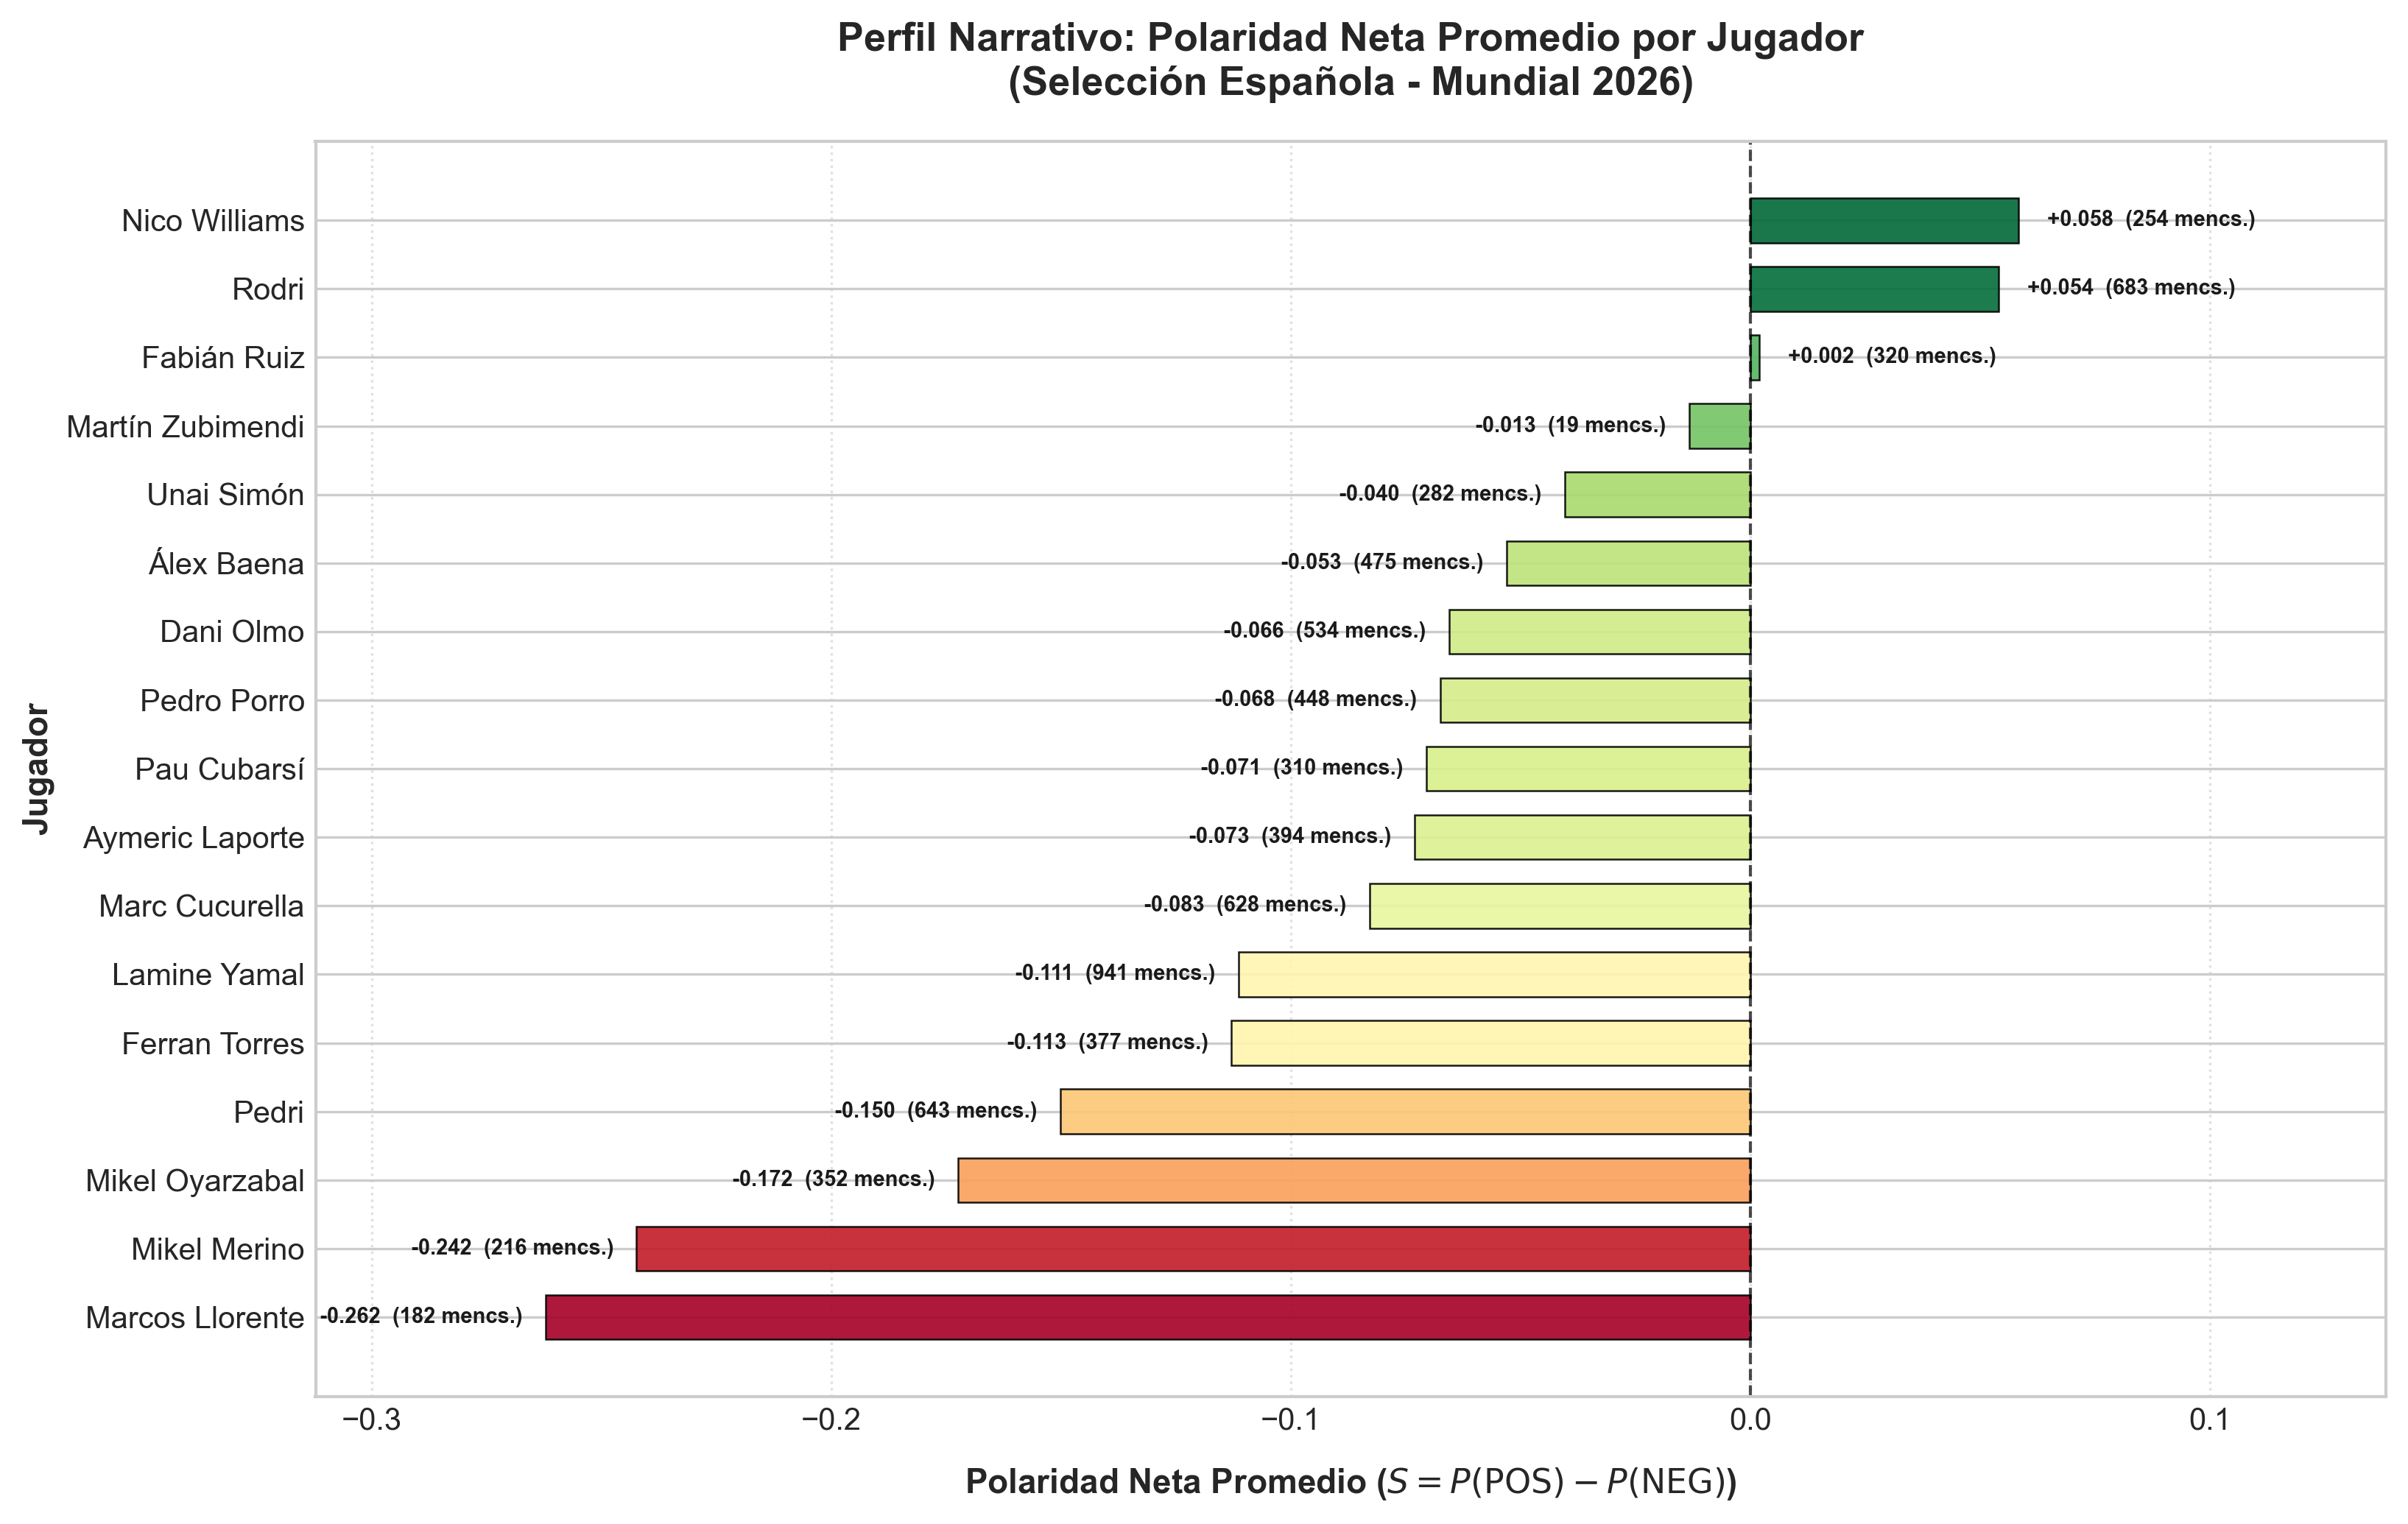

In [22]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# 1. Preparar datos a partir de player_stats_filtered
df_plot = player_stats_filtered.sort_values(by="polaridad_neta_promedio", ascending=True)

# 2. Configurar la figura
plt.figure(figsize=(11, 7), dpi=300)

# 3. Asignar paleta de degradado continuo: Rojo (Bajo) - Amarillo (Medio) - Verde (Alto)
# Normalizamos la variable para escalar el colormap a los límites exactos de nuestros datos
norm = mcolors.Normalize(vmin=df_plot['polaridad_neta_promedio'].min(), 
                         vmax=df_plot['polaridad_neta_promedio'].max())
cmap = cm.get_cmap('RdYlGn')
colors = cmap(norm(df_plot['polaridad_neta_promedio']))

# 4. Dibujar barras horizontales divergentes
bars = plt.barh(
    df_plot['players'], 
    df_plot['polaridad_neta_promedio'], 
    color=colors, 
    height=0.65, 
    edgecolor='black', 
    linewidth=0.6,
    alpha=0.9
)

# 5. Línea de referencia en cero (Eje neutro)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# 6. Etiquetas de valores exactos en las barras y volumen de menciones
for bar, mention in zip(bars, df_plot['menciones']):
    width = bar.get_width()
    offset = 0.005 if width >= 0 else -0.005
    ha_align = 'left' if width >= 0 else 'right'
    
    # Texto con la polaridad neta y las menciones totales
    plt.text(
        width + offset, 
        bar.get_y() + bar.get_height() / 2, 
        f" {width:+.3f}  ({mention} mencs.)", 
        va='center', 
        ha=ha_align, 
        fontsize=7, 
        fontweight='bold',
        color='#1a1a1a'
    )

# 7. Estilo y detalles
plt.title('Perfil Narrativo: Polaridad Neta Promedio por Jugador\n(Selección Española - Mundial 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Polaridad Neta Promedio ($S = P(\\text{POS}) - P(\\text{NEG})$)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Jugador', fontsize=11, fontweight='bold')

# Ajuste dinámico de los límites del eje X añadiendo un margen para que los textos no se corten
x_min = df_plot['polaridad_neta_promedio'].min()
x_max = df_plot['polaridad_neta_promedio'].max()
plt.xlim(x_min - 0.05, x_max + 0.08)

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# Guardar figura
output_img = os.path.join(processed_dir, "polaridad_jugadores_divergente.png")
plt.savefig(output_img, dpi=300)
plt.show()

## 5. Modelado Multimodal de la Dinámica Emocional: Índice de Euforia/Pánico ($I_t$)

En esta etapa integramos la dimensión acústica de la retransmisión con la polaridad semántica del texto para construir una serie temporal continua que capture la intensidad narrativa minuto a minuto a lo largo de cada partido.

---

### **1. Fundamento Teórico y Construcción del Índice ($I_t$)**

El análisis semántico de texto ($S_t$) permite identificar si el discurso es positivo o negativo, pero carece de la métrica de **intensidad física** que transmite la voz del locutor en eventos de alto impacto (gritos de gol, ocasiones claras de peligro o protestas). Para resolver esta limitación, combinamos ambas modalidades mediante la **Energía Cuadrática Media (RMS)** del audio:

1. **Intensidad Acústica Normalizada ($\text{RMS}_t$):** Se calcula el valor RMS en el dominio del tiempo para cada segmento narrativo $i$ sobre la señal de audio cargada a 16 kHz:
   $$\text{RMS}_i = \sqrt{\frac{1}{N} \sum_{n=1}^{N} y[n]^2}$$
   Posteriormente, la serie se escala en el rango $[0, 1]$ mediante una normalización Min-Max por partido para permitir comparaciones homogéneas.

2. **Índice Instantáneo de Euforia / Pánico ($I_t$):** Se define como el producto entre la intensidad acústica y la polaridad neta del sentimiento ($S_t = P(\text{POS})_t - P(\text{NEG})_t$):
   $$I_t = \text{RMS}_t \cdot S_t \quad \in [-1, 1]$$

   * **$I_t \gg 0$ (Euforia):** Alta intensidad de voz combinada con semántica positiva (ej. narración de un gol a favor o gran jugada).
   * **$I_t \ll 0$ (Pánico / Tensión):** Alta intensidad de voz combinada con semántica negativa (ej. ocasión clara encajada, gol rival o protesta).
   * **$I_t \approx 0$ (Neutralidad / Calma):** Momentos de posesión tranquila o narraciones sin sobresaltos acústicos.

---

### **2. Agregación Temporal y Tendencia (SMA 5)**

Para analizar la inercia del encuentro y evitar la distorsión por ruidos puntuales, los datos se agregan a frecuencia por minuto relativo de juego ($t_{\text{rel}}$) agrupando por periodo (`1P`, `2P`, `TE`). 

Sobre la serie temporal resultante, calculamos una **Media Móvil Simple de 5 minutos (SMA 5)** como indicador de la tendencia emocional subyacente, permitiendo identificar periodos sostenidos de dominio, tensión defensiva o estallidos colectivos.

Procesando señal de audio y construyendo el Índice de Euforia/Pánico...



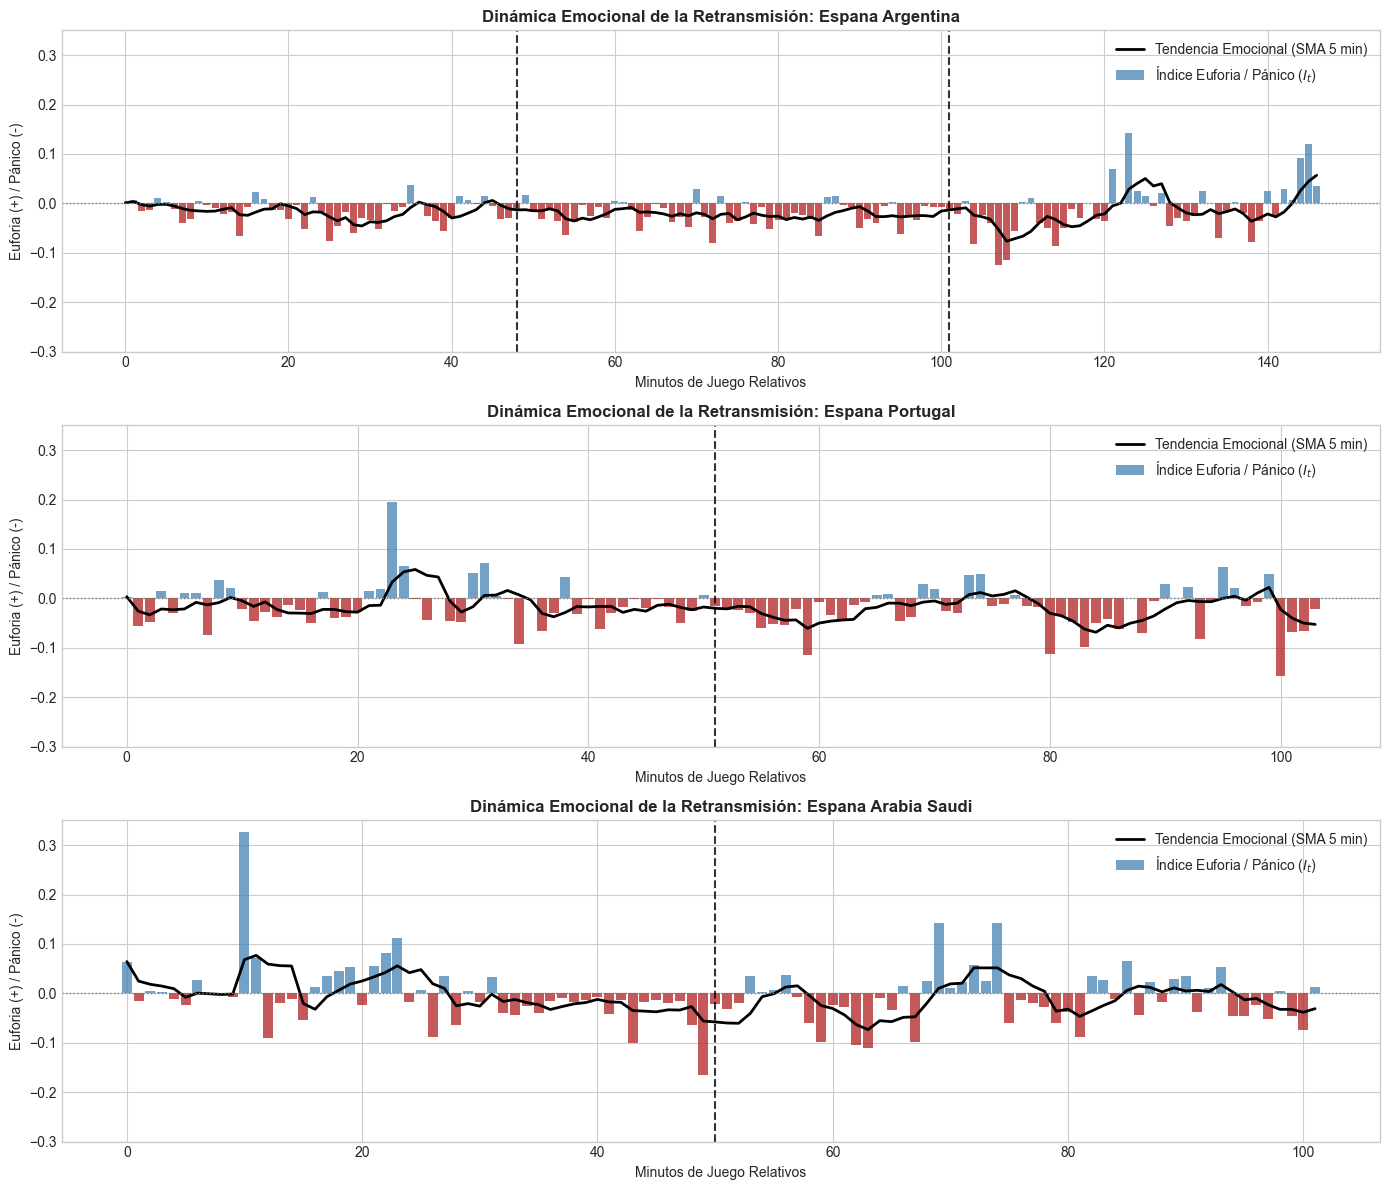

✔ Serie temporal exportada a: ..\data\processed\euphoria_panic_time_series.csv
✔ Gráfico con eje Y homogeneizado exportado a: ..\data\processed\indice_euforia_panico_timeline.png


In [36]:
import librosa

# Configuración estilística
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Configuración de directorios y carga del dataset NLP
data_dir = os.path.join("..", "data")
audio_dir = os.path.join(data_dir, "transcripts")
processed_dir = os.path.join(data_dir, "processed")

df_nlp = pd.read_parquet(os.path.join(processed_dir, "sentiment_ner_dataset.parquet"))

# Filtrar los partidos seleccionados
selected_matches = ['espana_argentina', 'espana_portugal', 'espana_arabia_saudi']
df_nlp = df_nlp[df_nlp['match_id'].isin(selected_matches)].copy()

# 2. Función optimizada para calcular la energía RMS del audio
def extract_audio_rms(match_id, df_match):
    """Extrae la energía RMS en el dominio del tiempo para cada segmento."""
    audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".mp3")]
    audio_file = next((f for f in audio_files if match_id.split('_')[1] in f.lower()), None)
    
    if not audio_file:
        return np.zeros(len(df_match))
        
    audio_path = os.path.join(audio_dir, audio_file)
    y, sr = librosa.load(audio_path, sr=16000, mono=True)
    
    rms_values = []
    for _, row in df_match.iterrows():
        start_sample = int(row['start'] * sr)
        end_sample = int(row['end'] * sr)
        
        y_segment = y[start_sample:end_sample]
        if len(y_segment) > 0:
            rms = np.sqrt(np.mean(y_segment**2))
        else:
            rms = 0.0
        rms_values.append(rms)
        
    return rms_values

# 3. Construcción de la Serie Temporal por Minuto ($t_{rel}$)
ts_data = []

print("Procesando señal de audio y construyendo el Índice de Euforia/Pánico...\n")
for match_id, df_match in df_nlp.groupby("match_id"):
    df_match = df_match.sort_values("relative_start").copy()
    
    # Extraer energía RMS
    df_match['audio_rms'] = extract_audio_rms(match_id, df_match)
    
    # Normalizar RMS (Min-Max) a [0, 1]
    max_rms = df_match['audio_rms'].max()
    if max_rms > 0:
        df_match['audio_rms'] = df_match['audio_rms'] / max_rms
        
    # Índice de Euforia/Pánico Instantáneo: I_t = Audio_RMS * Net_Polarity
    df_match['I_t'] = df_match['audio_rms'] * df_match['net_polarity']
    df_match['minute'] = (df_match['relative_start'] // 60).astype(int)
    
    # Agrupar por periodo y minuto
    df_minute = df_match.groupby(['period', 'minute']).agg(
        I_t_mean=('I_t', 'mean'),
        audio_rms_mean=('audio_rms', 'mean'),
        net_polarity_mean=('net_polarity', 'mean')
    ).reset_index()
    
    df_minute['match_id'] = match_id
    ts_data.append(df_minute)

df_ts = pd.concat(ts_data, ignore_index=True)

# 4. Visualización de la Evolución Temporal del Índice I_t (Eje Y Homogéneo)
fig, axes = plt.subplots(len(selected_matches), 1, figsize=(14, 4 * len(selected_matches)), sharex=False)
if len(selected_matches) == 1: axes = [axes]

for idx, match_id in enumerate(selected_matches):
    df_match_ts = df_ts[df_ts['match_id'] == match_id].sort_values(['period', 'minute']).reset_index(drop=True)
    
    if df_match_ts.empty:
        continue
        
    minutes = range(len(df_match_ts))
    i_t_values = df_match_ts['I_t_mean'].values
    
    ax = axes[idx]
    
    # Asignar colores a las barras: Azul para Euforia (+), Rojo para Pánico/Tensión (-)
    colors = ['firebrick' if val < 0 else 'steelblue' for val in i_t_values]
    
    ax.bar(minutes, i_t_values, color=colors, alpha=0.75, width=0.85, label='Índice Euforia / Pánico ($I_t$)')
    
    # Añadir una media móvil suave (SMA 5 minutos)
    sma_5 = pd.Series(i_t_values).rolling(window=5, min_periods=1).mean()
    ax.plot(minutes, sma_5, color='black', linewidth=2, linestyle='-', label='Tendencia Emocional (SMA 5 min)')
    
    # Línea de polaridad neutra (0)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    
    # Marcar cambios de periodo (1P, 2P, TE)
    period_changes = df_match_ts[df_match_ts['period'].ne(df_match_ts['period'].shift())].index[1:]
    for ci in period_changes:
        ax.axvline(x=ci, color='black', linestyle='--', alpha=0.8, linewidth=1.5)
        
    # --- HOMOGENEIZACIÓN DEL EJE Y ---
    ax.set_ylim(-0.30, 0.35)
    
    ax.set_title(f'Dinámica Emocional de la Retransmisión: {match_id.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Euforia (+) / Pánico (-)')
    ax.set_xlabel('Minutos de Juego Relativos')
    ax.legend(loc='upper right')

plt.tight_layout()
output_plot_path = os.path.join(processed_dir, "indice_euforia_panico_timeline.png")
plt.savefig(output_plot_path, dpi=300)
plt.show()

# 5. Guardar la serie temporal agregada
output_ts_path = os.path.join(processed_dir, "euphoria_panic_time_series.csv")
df_ts.to_csv(output_ts_path, index=False, encoding="utf-8-sig")

print(f"✔ Serie temporal exportada a: {output_ts_path}")
print(f"✔ Gráfico exportado a: {output_plot_path}")

### **A. España vs. Argentina: Partido Táctico y Combate Nulo (0-0)**
* **Dominio sin Mordiente:** La serie temporal refleja una primera parte muy equilibrada, con la tendencia emocional (SMA 5) oscilando en valores neutros, muy pegada a la línea de 0. Los picos azules son escasos y de baja intensidad ($I_t < 0.05$), lo que concuerda con un encuentro bloqueado, de mucho respeto táctico y pocas ocasiones claras, donde España tiene la posesión pero no logra desbordar.
* **El Foco de Tensión:** Destaca un valle negativo prolongado hacia el final de la primera parte y en el inicio de la segunda ($I_t$ rozando $-0.10$). Este tramo coincide con la aparición de Messi, la falta sobre Rodri, las protestas y la tarjeta amarilla a Lisandro Martínez, momentos que los comentaristas narran con un alto nivel de tensión acústica y semántica, evidenciando el "otro fútbol" y la agresividad de la final. 
* **Ausencia de Clímax:** A diferencia de otros encuentros, el gráfico no muestra el estallido de euforia característico de un gol. La narrativa se mantiene contenida y expectante ante el resultado gafas (0-0). Todo cambia cuando llega la prorroga donde se ve el pico euforico del gol de Ferran Torres, el nerviosismo por la agonia final española y la euforia final al acabar el partido y proclamarse españa campeona del mundo

---

### **B. España vs. Portugal: El Muro Luso y el Susto de Nuno Mendes**
* **La Única Gran Oportunidad:** El gráfico está protagonizado por un único pico monumental de euforia en torno al minuto relativo 25 (no coincide con real real) ($I_t \approx +0.20$), correlacionado con la ocasión más clara de España: el remate de Oyarzabal que, tras una brillante asistencia de Dani Olmo de primeras
* **Pánico a la Contra:** Tras ese pico, la tendencia cae inmediatamente a terreno negativo (pánico/tensión), provocado por la contra rapidísima de Portugal orquestada por Nuno Mendes, que culmina con un tiro al palo. El modelo captura a la perfección esta transición emocional instantánea de la euforia absoluta al susto defensivo.
* **Frustración y Bloqueo:** El resto del encuentro dibuja un patrón de micro-valles rojos. Esto ilustra la incomodidad de España intentando romper el repliegue bajo de Portugal, la frustración por la falta de fluidez en el campo seco y el trabajo defensivo de Joao Félix secando a Lamine Yamal.
* **Gol final:** Al final de la grafica se pueden ver picos euforicos tras el gol de mikel mireno, seguidos de minutos de panico tras el acoso final de portugal a la porteria de Unai Simon

---

### **C. España vs. Arabia Saudí: Euforia Desatada y Dominio Plácido (4-0)**
* **Arranque Arrollador:** La gráfica es la definición visual de un monólogo ofensivo. España sale en tromba y el índice $I_t$ registra el mayor pico de todo el análisis ($I_t > +0.30$) en el minuto 10, que se corresponde con el gol inaugural de Lamine Yamal.
* **Picos Secuenciales:** A diferencia de las finales cerradas, aquí la euforia es cíclica. Se observan nuevos picos prominentes (barras azules que superan el $+0.10$) en los minutos 23 y 65, que capturan a la perfección los goles consecutivos de Mikel Oyarzabal y el cuarto gol anotado (o en propia puerta tras el tiro) por Marc Cucurella[cite: 3].
* **Control Absoluto:** La línea de tendencia general se sitúa predominantemente en el sector positivo de la gráfica. No hay valles de pánico significativos, confirmando la relajación de la narrativa ante un partido totalmente resuelto donde el guardameta español, Unai Simón, apenas tiene que intervenir[cite: 3].

---

### **Conclusión del Modelado Emocional Multimodal**
El **Índice de Euforia/Pánico ($I_t$)** demuestra una robustez extraordinaria para destilar la historia de un partido. Las variaciones de la energía RMS de la voz, escaladas por el sentimiento de la locución, dibujan con precisión milimétrica la estructura de las eliminatorias: la tensión asfixiante de las finales cerradas frente a la holgura acústica y festiva de las goleadas.